In [ ]:
import pandas as pd
import joblib
import numpy as np
import xgboost as xgb


In [ ]:
model=xgb.XGBRFClassifier()
model.load_model('faers_xgb_severity_v1.json')
feature_cols=joblib.load('feature_cols_v1.pkl')

In [ ]:
row=pd.DataFrame([dict.fromkeys(feature_cols,0)],dtype='float32')

In [ ]:
drug_names = [c
              for c in feature_cols
              if c.startswith('drug_')]

print(f"Total: {len(drug_names)}")
print(sorted(drug_names))
with open('drug_list.txt', 'w') as f:
    for name in sorted(drug_names):
        f.write(name + '\n')

print("Saved to drug_list.txt")

Total: 300
['drug_ACCRUFER', 'drug_ACETAMINOPHEN', 'drug_ACOLTREMON', 'drug_ACTEMRA', 'drug_ADALIMUMAB', 'drug_ADBRY', 'drug_AIMOVIG', 'drug_ALBUTEROL', 'drug_ALBUTEROL_SULFATE', 'drug_ALENDRONATE_SODIUM', 'drug_ALENDRONIC_ACID', 'drug_ALPRAZOLAM', 'drug_AMLODIPINE', 'drug_AMOXICILLIN', 'drug_APIXABAN', 'drug_ARAVA', 'drug_ARIKAYCE', 'drug_ARIPIPRAZOLE', 'drug_ASPIRIN', 'drug_ATEZOLIZUMAB', 'drug_ATORVASTATIN', 'drug_AVASTIN', 'drug_AYVAKIT', 'drug_AZACITIDINE', 'drug_AZATHIOPRINE', 'drug_AZITHROMYCIN', 'drug_BENLYSTA', 'drug_BEVACIZUMAB', 'drug_BIMEKIZUMAB', 'drug_BIMZELX', 'drug_BISOPROLOL', 'drug_BORTEZOMIB', 'drug_BOTOX', 'drug_BREZTRI', 'drug_BUDESONIDE', 'drug_BUDESONIDE\\FORMOTEROL\\GLYCOPYRRONIUM', 'drug_BUPRENORPHINE', 'drug_BUPROPION', 'drug_CABOMETYX', 'drug_CALCIUM_CARBONATE', 'drug_CANDESARTAN', 'drug_CANNABIS_SATIVA_SUBSP._INDICA_TOP', 'drug_CAPECITABINE', 'drug_CARBIDOPA\\LEVODOPA', 'drug_CARBOPLATIN', 'drug_CARVYKTI', 'drug_CELEBREX', 'drug_CELECOXIB', 'drug_CEQUA', 'dr

**syntoms**

In [ ]:
indi_names = [c
              for c in feature_cols
              if c.startswith('indi_')]

print(f"Total: {len(indi_names)}")
print(sorted(indi_names))
with open('indi_list.txt', 'w') as f:
    for name in sorted(indi_names):
        f.write(name + '\n')

print("Saved to indi_list.txt")

Total: 100
['indi_ACUTE_MYELOID_LEUKAEMIA', 'indi_ADVERSE_DRUG_REACTION', 'indi_ANKYLOSING_SPONDYLITIS', 'indi_ANTICOAGULANT_THERAPY', 'indi_ANXIETY', 'indi_ARTHRALGIA', 'indi_ARTHRITIS', 'indi_ASTHMA', 'indi_ATRIAL_FIBRILLATION', 'indi_ATTENTION_DEFICIT_HYPERACTIVITY_DISORDER', 'indi_BACK_PAIN', 'indi_BIPOLAR_DISORDER', 'indi_BLOOD_CHOLESTEROL_INCREASED', 'indi_BLOOD_GLUCOSE_INCREASED', 'indi_BREAST_CANCER', 'indi_BREAST_CANCER_FEMALE', 'indi_BREAST_CANCER_METASTATIC', 'indi_CARDIAC_FAILURE', 'indi_CHRONIC_LYMPHOCYTIC_LEUKAEMIA', 'indi_CHRONIC_MYELOID_LEUKAEMIA', 'indi_CHRONIC_OBSTRUCTIVE_PULMONARY_DISEASE', 'indi_COLITIS_ULCERATIVE', 'indi_COLON_CANCER', 'indi_CONSTIPATION', 'indi_CONTRACEPTION', "indi_CROHN'S_DISEASE", 'indi_CYSTIC_FIBROSIS', "indi_DEMENTIA_ALZHEIMER'S_TYPE", 'indi_DEPRESSION', 'indi_DERMATITIS', 'indi_DERMATITIS_ATOPIC', 'indi_DIABETES_MELLITUS', 'indi_DIARRHOEA', 'indi_DIFFUSE_LARGE_B_CELL_LYMPHOMA', 'indi_DRY_EYE', 'indi_DYSLIPIDAEMIA', 'indi_ECZEMA', 'indi_EOSIN

Enter age (years): 26
Sex (0=Male, 1=Female): 0
Weight (kg): 65
Dose amount (mg): 100
Number of drugs currently taking: 2
Drug name: drug_ALENDRONIC_ACID
Indication: indi_SCHIZOPHRENIA
Report type {"Expedited":2, "30-Day":1, "Periodic, Direct":0}: 1
Enter 1 if reaction abated when drug therapy was stopped else 00
Enter 1 if reaction recurred when drug therapy was restarted else 01
Name: ken
[[0.10967581 0.12395168 0.21340713 0.5285258  0.02443954]]


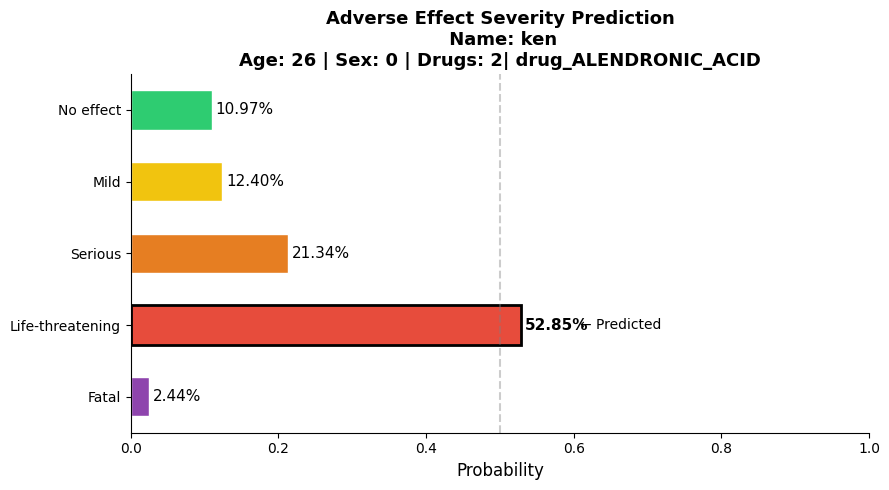

In [ ]:
# ── INPUTS
age      = int(input('Enter age (years): '))
sex      = int(input('Sex (0=Male, 1=Female): '))
wt_kg    = float(input('Weight (kg): '))
dose_amt = float(input('Dose amount (mg): '))
d_count  = int(input('Number of drugs currently taking: '))
drug     = input('Drug name: ')
indi     = input('Indication: ')
rept     = int(input(f'Report type {{"Expedited":2, "30-Day":1, "Periodic, Direct":0}}: '))
dechal_pos=int(input('Enter 1 if reaction abated when drug therapy was stopped else 0'))
rechal_pos=int(input('Enter 1 if reaction recurred when drug therapy was restarted else 0'))
name     =input('Name: ')

# age_group
def get_age_group(age):
    if age <= 2:   return 0   # infant
    elif age <= 12: return 1  # child
    elif age <= 18: return 2  # adolescent
    elif age <= 40: return 3  # adult
    elif age <= 62: return 4  # middle-aged
    elif age <= 85: return 5  # senior
    else:           return 6  # 85+

# poly_risk (from your pd.cut logic)
poly = int(pd.cut([d_count], bins=[-1,1,2,4,9999], labels=[0,1,2,3])[0])

# ── FILL ROW ──────────────────────────────────────────────────────────
row['age_years']       = age
row['age_group']       = get_age_group(age)
row['missing_age']     = 0                  # user provided it

row['sex_enc']         = sex

row['wt_kg']           = wt_kg
row['missing_wt']      = 0                  # user provided it

row['dose_amt_val']    = dose_amt
row['missing_dose']    = 0                  # user provided it

row['n_drugs']         = d_count
row['poly_risk']       = poly               # from n_drugs

row['rept_enc']        = rept
row['indication_count']= 1                  # user enters 1 indication
row['occp_enc']        = 4                  # default: MD reporter
row['is_us']           = 1                  # default: US report

row['dechal_pos']      = dechal_pos
row['rechal_pos']      = rechal_pos

row[drug]              = 1
row[indi]              = 1
probs = model.predict_proba(row)

print(probs)
#ploting
import matplotlib.pyplot as plt
import numpy as np

probs_flat = probs[0]
original_classes = [0, 1, 3, 4, 5]
severity_labels = ['No effect', 'Mild', 'Serious', 'Life-threatening', 'Fatal']

colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
predicted_idx = probs_flat.argmax()

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(severity_labels, probs_flat, color=colors, edgecolor='white',
               height=0.55)

# Highlight predicted bar
bars[predicted_idx].set_edgecolor('black')
bars[predicted_idx].set_linewidth(2)

# Probability labels on bars
for i, (bar, prob) in enumerate(zip(bars, probs_flat)):
    ax.text(prob + 0.005, bar.get_y() + bar.get_height()/2,
            f'{prob:.2%}', va='center', fontsize=11,
            fontweight='bold' if i == predicted_idx else 'normal')

# Predicted annotation
ax.annotate(f'← Predicted',
            xy=(probs_flat[predicted_idx], predicted_idx),
            xytext=(probs_flat[predicted_idx] + 0.08, predicted_idx),
            fontsize=10, color='black', va='center')

ax.set_xlim(0, 1.0)
ax.set_xlabel('Probability', fontsize=12)
ax.set_title(f'Adverse Effect Severity Prediction\n Name: {name}\n'
             f'Age: {age} | Sex: {sex} | Drugs: {d_count}| {drug}',
             fontsize=13, fontweight='bold')
ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4, label='50% threshold')
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()